#**스마트폰 센서 데이터 기반 모션 분류**
# 단계2 : 기본 모델링


## 0.미션3

* 데이터 전처리
    * 가변수화, 데이터 분할, NaN 확인 및 조치, 스케일링 등 필요한 전처리 수행
* 다양한 딥러닝 구조의 모델로 분류 모델 생성
    * 최소 4개 이상 모델링 수행
    * 각 모델별 최소 5회 반복수행해서 얻은 성능의 평균으로 비교
    * 각 모델의 성능을 저장하는 별도 데이터 프레임을 만들고 비교
* 옵션 : 다음 사항은 선택사항입니다. 시간이 허용하는 범위 내에서 수행하세요.
    * 상위 N개 변수를 선정하여 모델링 및 성능 비교
        * 모델링에 항상 모든 변수가 필요한 것은 아닙니다.
        * 변수 중요도 상위 N개를 선정하여 모델링하고 타 모델과 성능을 비교하세요.
        * 상위 N개를 선택하는 방법은, 변수를 하나씩 늘려가며 모델링 및 성능 검증을 수행하여 적절한 지점을 찾는 것입니다.
* 성능 가이드
    * Accuracy : 0.90 ~ 0.99

## 1.환경설정

* 세부 요구사항
    - 경로 설정 : 구글콜랩
        * 구글 드라이브 바로 밑에 project3 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### (1) 경로 설정

* 구글 드라이브 연결

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
path = '/content/drive/MyDrive/project3/'

### (2) 라이브러리 불러오기

* 라이브러리 로딩

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input
from keras.backend import clear_session
from keras.optimizers import Adam

In [71]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

* 세부 요구사항
    * 칼럼 삭제 : data01_train.csv와 data01_test.csv 에서 'subject' 칼럼은 불필요하므로 삭제합니다.

#### 1) 데이터로딩

In [72]:
train=pd.read_csv(path+'data01_train.csv')
test=pd.read_csv(path+'data01_test.csv')
features=pd.read_csv(path+'features.csv')

In [73]:
col='subject'
train.drop(col, axis=1, inplace=True)
test.drop(col, axis=1, inplace=True)

#### 2) 기본 정보 조회

In [74]:
train.shape

(5881, 562)

In [75]:
train.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


In [76]:
train.columns

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-skewness()', 'fBodyBodyGyroJerkMag-kurtosis()',
       'angle(tBodyAccMean,gravity)', 'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'Activity'],
      dtype='object', length=562)

In [77]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Columns: 562 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), object(1)
memory usage: 25.2+ MB


## **2. 데이터 전처리**

* 가변수화, 데이터 분할, NaN 확인 및 조치, 스케일링 등 필요한 전처리를 수행한다.


### (1) 데이터 분할1 : x, y

* 세부 요구사항
    - x, y로 분할합니다.

In [78]:
from sklearn.model_selection import train_test_split
target='Activity'
x=train.drop(target, axis=1)
y=train[target]

### (2) 스케일링


* 세부 요구사항
    - 스케일링을 필요로 하는 알고리즘 사용을 위해서 코드 수행
    - min-max 방식 혹은 standard 방식 중 한가지 사용.

In [79]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_s=scaler.fit_transform(x)

### (3) Y 전처리
* integer encoding : LabelEncoder
* (필요시) one-hot encoding

In [80]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_e = le.fit_transform(y)
print(y_e)

[2 0 2 ... 0 5 1]


In [81]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
y_o = ohe.fit_transform(train[['Activity']]).toarray()
print(y_o)

[[0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 ...
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0.]]


### (4) 데이터분할2 : train, validation

* 세부 요구사항
    - train : val = 8 : 2 혹은 7 : 3
    - random_state 옵션을 사용하여 다른 모델과 비교를 위해 성능이 재현되도록 합니다.

In [82]:
x_train, x_val, y_train, y_val = train_test_split(x_s, y_o, test_size=0.2, random_state=10, stratify=y_o)

## **3. 기본 모델링**



* 세부 요구사항
    - 모델1 : Base line 모델
        * Hidden Layer 없이 모델 생성
    - 모델2 : 복잡한 모델 생성
        * 최소 5개 이상의 은닉층을 추가한 모델
    - 모델3 ~ n : 튜닝 모델
        * 학습률, epoch 등 조정
        * 모델2에 과적합을 방지하기 위한 규제 기법 추가
        * Accuracy 최대화 시키는 모델 생성하기
    - 각 모델은 최소 5번 반복수행해서 얻은 성능의 평균값을 기록

In [83]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input, Concatenate
from keras.backend import clear_session
from keras.optimizers import Adam
from keras.layers import Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.models import Model
y_val=np.argmax(y_val, axis=1)
nf=x_train.shape[1]
nf

561

### (1) 모델1
- 기본 모델

=== Model Training: Repeat 1/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


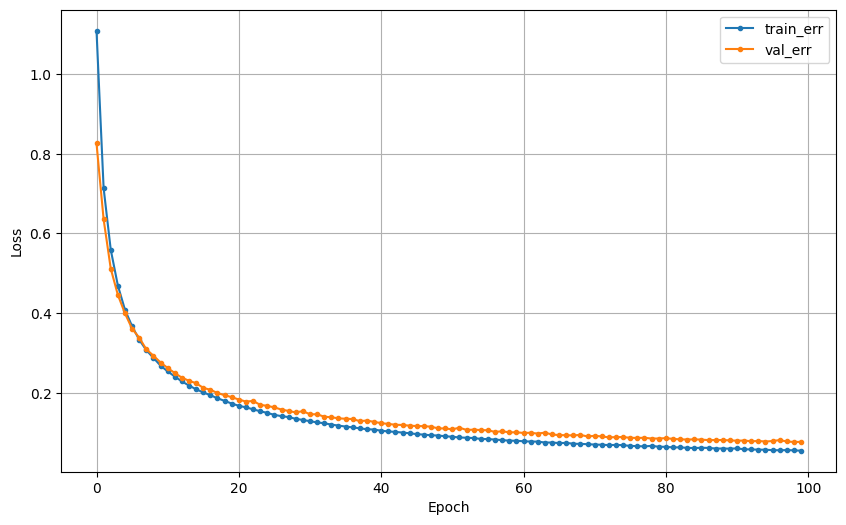

[[223   0   0   0   0   0]
 [  1 194  11   0   0   0]
 [  0   7 211   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   3   1 168]]
Accuracy: 0.9796
Precision: 0.9807
Recall: 0.9802
F1 Score: 0.9804
=== Model Training: Repeat 2/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


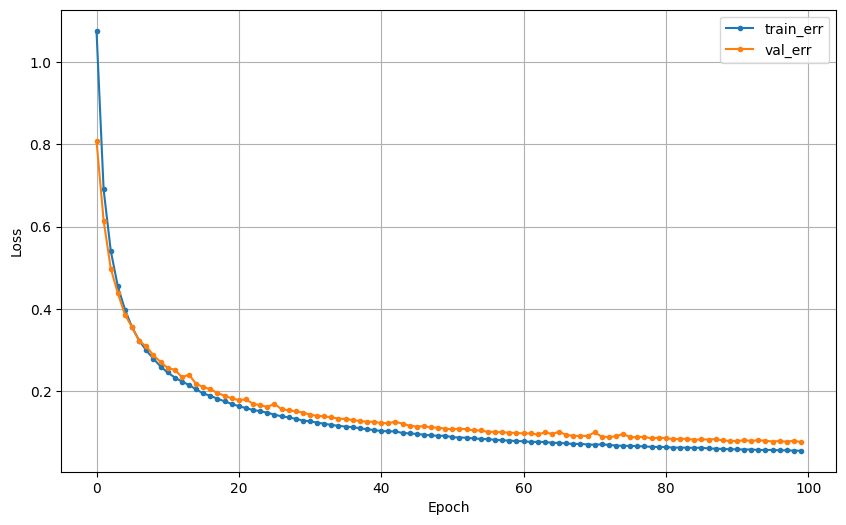

[[223   0   0   0   0   0]
 [  1 193  12   0   0   0]
 [  0   6 212   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 157   1]
 [  0   0   0   1   0 171]]
Accuracy: 0.9813
Precision: 0.9825
Recall: 0.9820
F1 Score: 0.9822
=== Model Training: Repeat 3/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


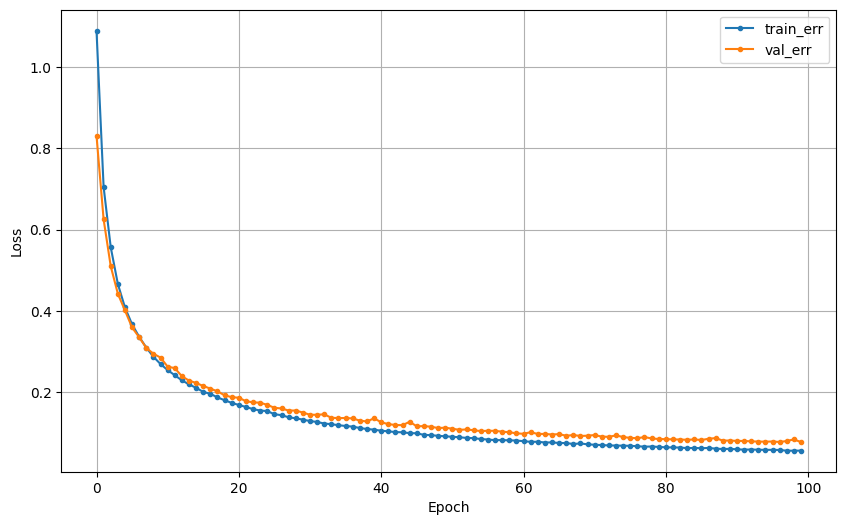

[[223   0   0   0   0   0]
 [  1 191  14   0   0   0]
 [  0   6 212   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   2   0 170]]
Accuracy: 0.9796
Precision: 0.9812
Recall: 0.9805
F1 Score: 0.9807
=== Model Training: Repeat 4/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


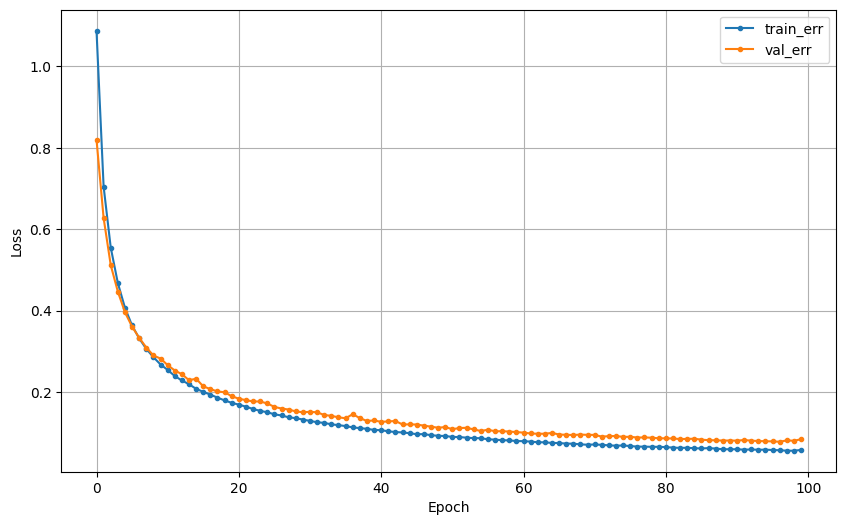

[[223   0   0   0   0   0]
 [  1 186  19   0   0   0]
 [  0   4 214   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   1   1 170]]
Accuracy: 0.9771
Precision: 0.9793
Recall: 0.9780
F1 Score: 0.9782
=== Model Training: Repeat 5/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


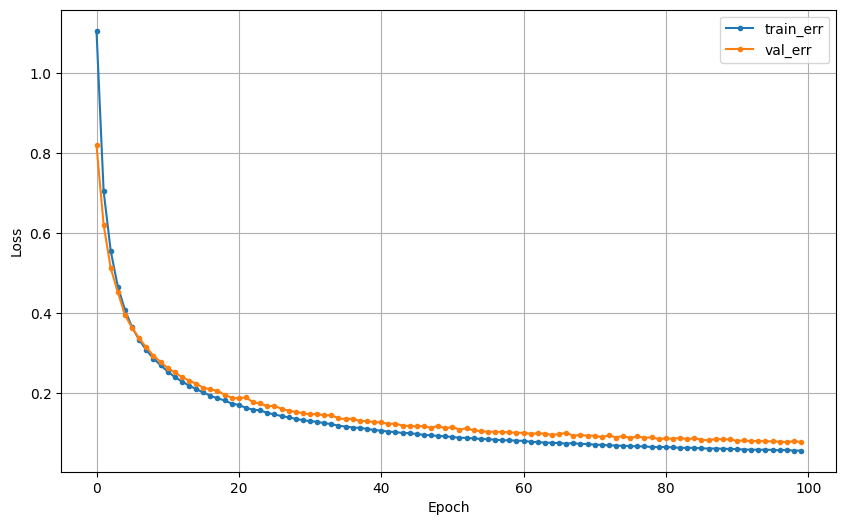

[[223   0   0   0   0   0]
 [  1 200   5   0   0   0]
 [  0  12 206   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   3   1 168]]
Accuracy: 0.9805
Precision: 0.9814
Recall: 0.9813
F1 Score: 0.9812

=== Average Results ===
Average Accuracy: 0.9796
Average Precision: 0.9810
Average Recall: 0.9804
Average F1 Score: 0.9806


In [84]:
n_repeats = 5

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []


for i in range(n_repeats):
  print(f"=== Model Training: Repeat {i+1}/{n_repeats} ===")

  clear_session()
  model3=Sequential([Input(shape=(nf,)),
                  Dense(6,activation='softmax')
                  ])
  # 모델 컴파일 및 학습
  model3.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy')
  hist = model3.fit(x_train, y_train,
                    validation_split=0.2,
                    epochs=100,
                    verbose=0).history

  # 예측 및 성능 평가
  pred = model3.predict(x_val)
  pred_y = np.argmax(pred, axis=1)

  # 분류 보고서에서 주요 지표 추출
  report = classification_report(y_val, pred_y, output_dict=True)

  # 성능 지표 기록
  accuracy_list.append(report['accuracy'])
  precision_list.append(report['macro avg']['precision'])
  recall_list.append(report['macro avg']['recall'])
  f1_list.append(report['macro avg']['f1-score'])

  # 학습 곡선 출력
  dl_history_plot(hist)

  # 출력 (개별 결과)
  print(confusion_matrix(y_val, pred_y))
  print(f"Accuracy: {report['accuracy']:.4f}")
  print(f"Precision: {report['macro avg']['precision']:.4f}")
  print(f"Recall: {report['macro avg']['recall']:.4f}")
  print(f"F1 Score: {report['macro avg']['f1-score']:.4f}")
  print("==============================================")

# 평균값 출력
print("\n=== Average Results ===")
print(f"Average Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1 Score: {np.mean(f1_list):.4f}")

### (2) 모델2
- HL 노드 784 -> 16 까지 구성

=== Model Training: Repeat 1/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


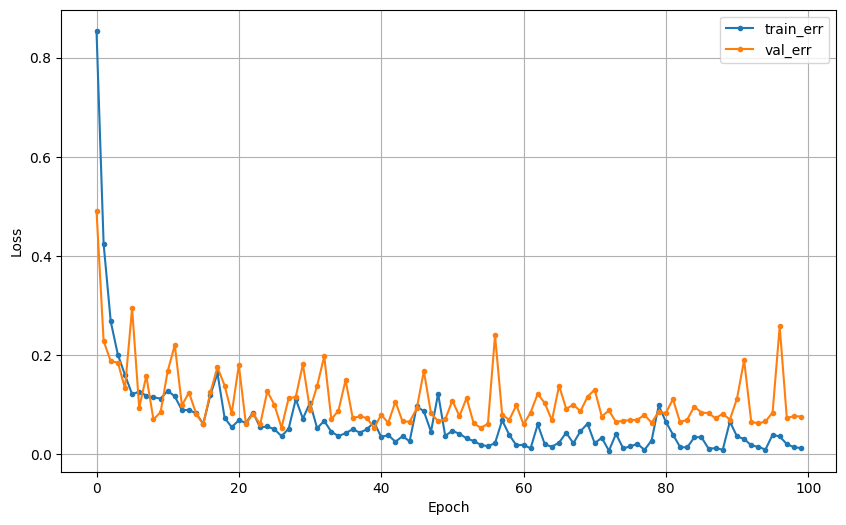

[[223   0   0   0   0   0]
 [  0 193  13   0   0   0]
 [  0   4 214   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   1   1 170]]
Accuracy: 0.9830
Precision: 0.9842
Recall: 0.9837
F1 Score: 0.9838
=== Model Training: Repeat 2/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


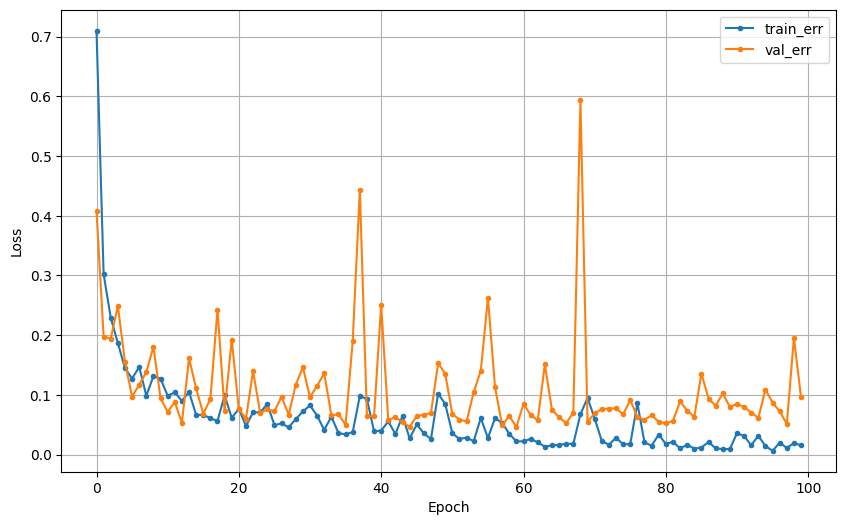

[[223   0   0   0   0   0]
 [  1 192  13   0   0   0]
 [  0   5 213   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   2   0 170]]
Accuracy: 0.9813
Precision: 0.9828
Recall: 0.9821
F1 Score: 0.9823
=== Model Training: Repeat 3/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


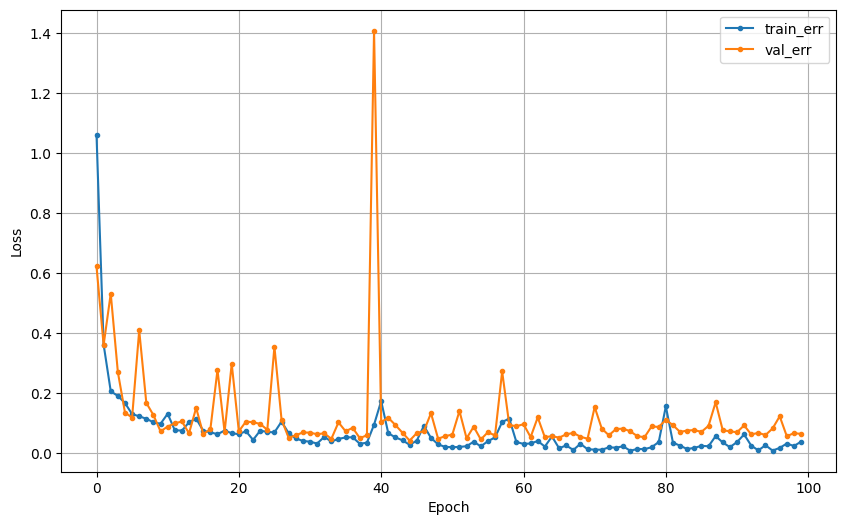

[[223   0   0   0   0   0]
 [  1 204   1   0   0   0]
 [  0   7 211   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   3   0 169]]
Accuracy: 0.9890
Precision: 0.9895
Recall: 0.9893
F1 Score: 0.9893
=== Model Training: Repeat 4/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


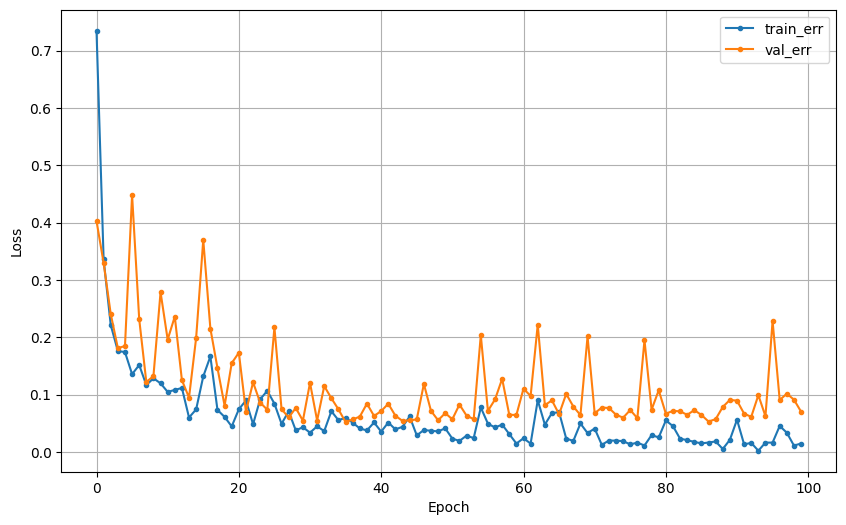

[[223   0   0   0   0   0]
 [  1 202   3   0   0   0]
 [  0   9 209   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   2   0 170]]
Accuracy: 0.9864
Precision: 0.9872
Recall: 0.9871
F1 Score: 0.9871
=== Model Training: Repeat 5/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


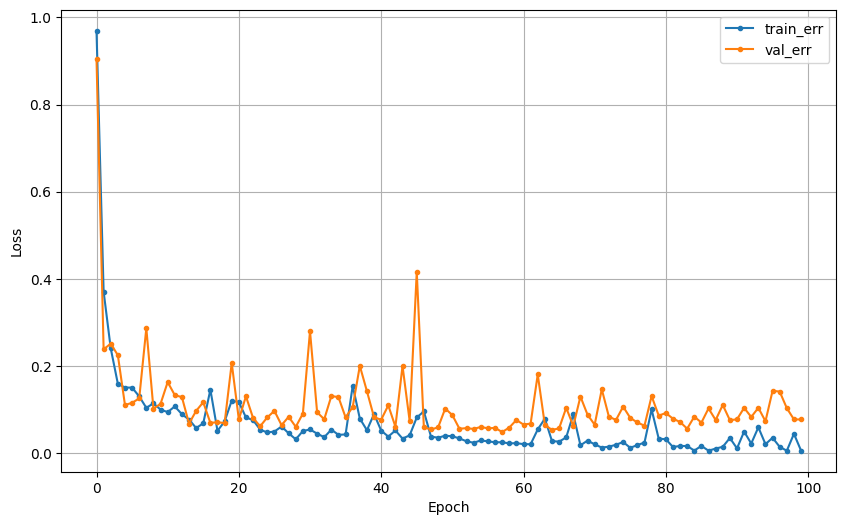

[[223   0   0   0   0   0]
 [  1 204   1   0   0   0]
 [  0   6 212   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   1 156   1]
 [  0   0   0   1   0 171]]
Accuracy: 0.9898
Precision: 0.9901
Recall: 0.9899
F1 Score: 0.9900

=== Average Results ===
Average Accuracy: 0.9859
Average Precision: 0.9868
Average Recall: 0.9864
Average F1 Score: 0.9865


In [85]:
n_repeats = 5
p=0.2

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []


for i in range(n_repeats):
  print(f"=== Model Training: Repeat {i+1}/{n_repeats} ===")

  clear_session()

  model3 = Sequential([Input(shape=(nf, )),
                     Dense(784, activation='relu'),
                     Dense(512, activation='relu'),
                     Dense(256, activation='relu'),
                     Dense(128, activation='relu'),
                     Dense(64, activation='relu'),
                     Dense(32, activation='relu'),
                     Dense(16, activation='relu'),
                     Dense(6, activation='softmax')])


  # 모델 컴파일 및 학습
  model3.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy')
  hist = model3.fit(x_train, y_train,
                    validation_split=0.2,
                    epochs=100,
                    verbose=0).history

  # 예측 및 성능 평가
  pred = model3.predict(x_val)
  pred_y = np.argmax(pred, axis=1)

  # 분류 보고서에서 주요 지표 추출
  report = classification_report(y_val, pred_y, output_dict=True)

  # 성능 지표 기록
  accuracy_list.append(report['accuracy'])
  precision_list.append(report['macro avg']['precision'])
  recall_list.append(report['macro avg']['recall'])
  f1_list.append(report['macro avg']['f1-score'])

  # 학습 곡선 출력
  dl_history_plot(hist)

  # 출력 (개별 결과)
  print(confusion_matrix(y_val, pred_y))
  print(f"Accuracy: {report['accuracy']:.4f}")
  print(f"Precision: {report['macro avg']['precision']:.4f}")
  print(f"Recall: {report['macro avg']['recall']:.4f}")
  print(f"F1 Score: {report['macro avg']['f1-score']:.4f}")
  print("==============================================")

# 평균값 출력
print("\n=== Average Results ===")
print(f"Average Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1 Score: {np.mean(f1_list):.4f}")

### (3) 모델3
- HL 노드 512 -> 8 까지 총 7계층으로 구현
- Dropout = 0.2
- es : min_delta = 0.001, patience = 20
- epochs = 150

=== Model Training: Repeat 1/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


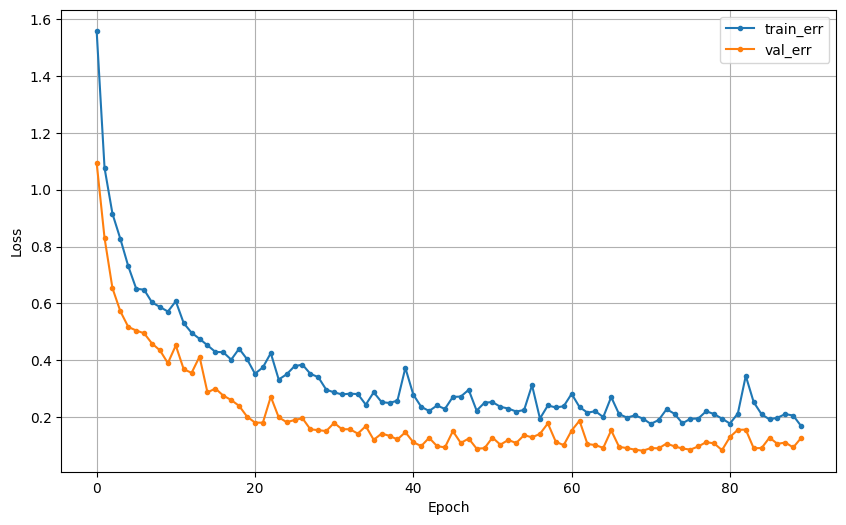

[[223   0   0   0   0   0]
 [  1 202   3   0   0   0]
 [  0  10 208   0   0   0]
 [  0   0   0 197   2   1]
 [  0   0   0   0 158   0]
 [  0   0   0   2  14 156]]
Accuracy: 0.9720
Precision: 0.9710
Recall: 0.9711
F1 Score: 0.9703
=== Model Training: Repeat 2/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


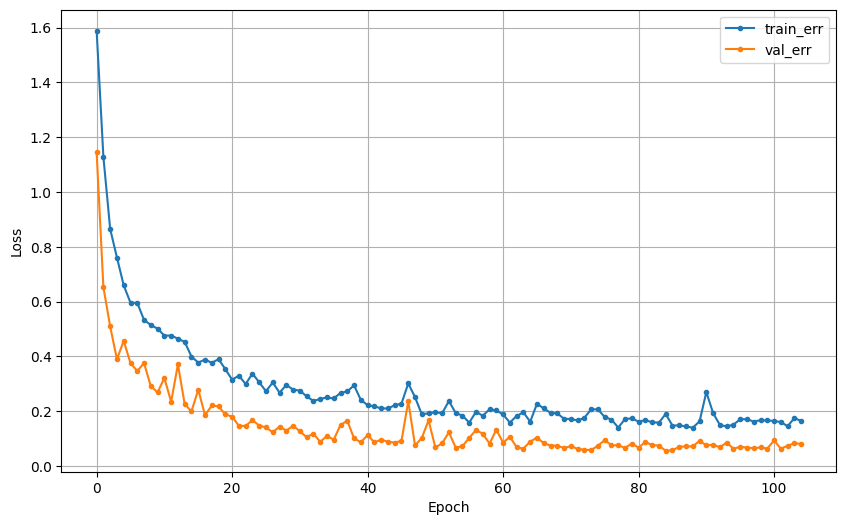

[[223   0   0   0   0   0]
 [  1 180  25   0   0   0]
 [  0   1 217   0   0   0]
 [  0   0   0 194   0   6]
 [  0   0   0   0 158   0]
 [  0   0   0   0   1 171]]
Accuracy: 0.9711
Precision: 0.9744
Recall: 0.9722
F1 Score: 0.9722
=== Model Training: Repeat 3/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


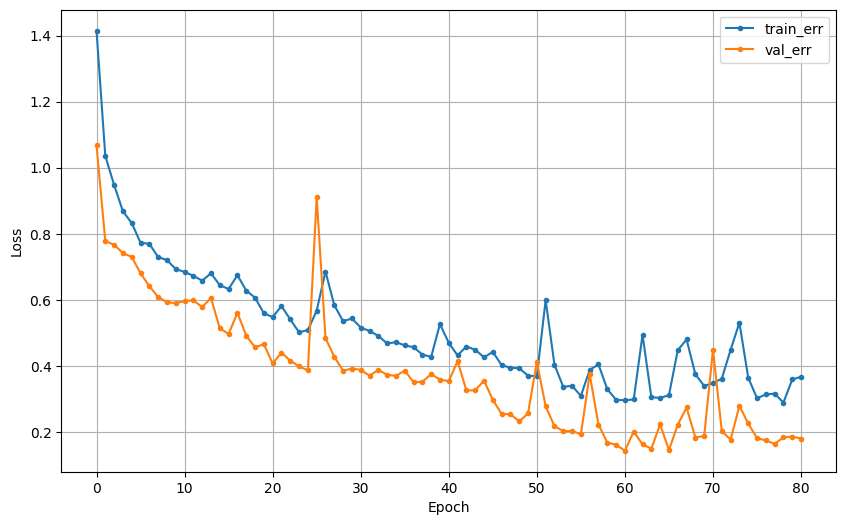

[[223   0   0   0   0   0]
 [  1 205   0   0   0   0]
 [  0  20 198   0   0   0]
 [  0   0   0 197   0   3]
 [  0   0   0   2 128  28]
 [  0   0   0   1   0 171]]
Accuracy: 0.9533
Precision: 0.9564
Recall: 0.9488
F1 Score: 0.9493
=== Model Training: Repeat 4/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


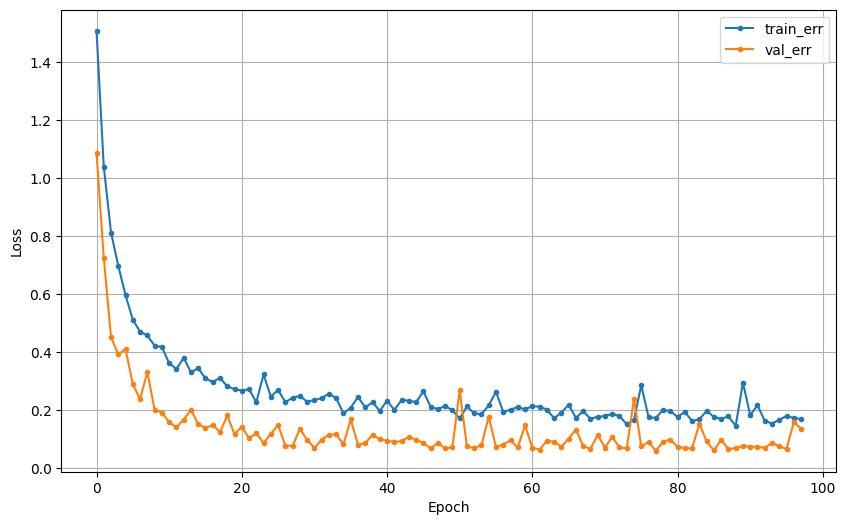

[[223   0   0   0   0   0]
 [  1 189  16   0   0   0]
 [  0   3 215   0   0   0]
 [  0   0   0 200   0   0]
 [  0   0   0   6 148   4]
 [  0   0   0  11   0 161]]
Accuracy: 0.9652
Precision: 0.9680
Recall: 0.9627
F1 Score: 0.9645
=== Model Training: Repeat 5/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


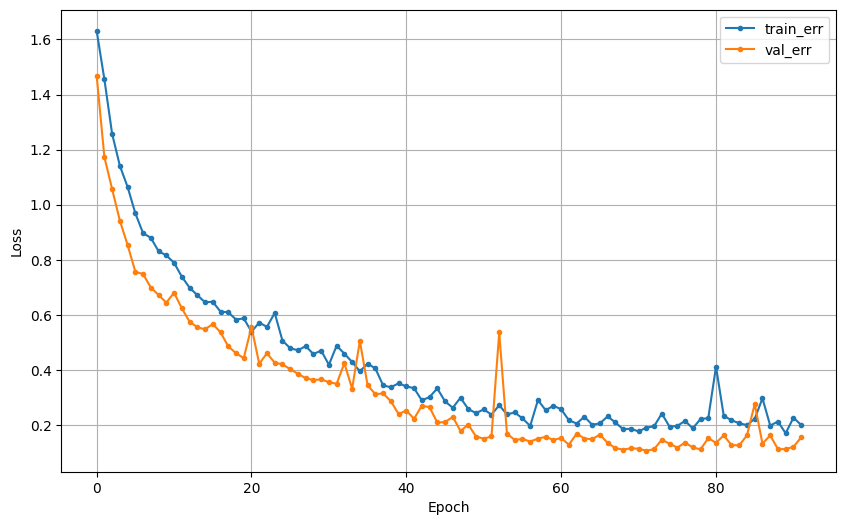

[[223   0   0   0   0   0]
 [  1 205   0   0   0   0]
 [  0  58 160   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   1   0 171]]
Accuracy: 0.9482
Precision: 0.9607
Recall: 0.9530
F1 Score: 0.9513

=== Average Results ===
Average Accuracy: 0.9619
Average Precision: 0.9661
Average Recall: 0.9616
Average F1 Score: 0.9615


In [86]:
n_repeats = 5
p=0.2

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []


for i in range(n_repeats):
  print(f"=== Model Training: Repeat {i+1}/{n_repeats} ===")

  clear_session()

  model3 = Sequential([
    Input(shape=(nf,)),
    Dense(512, activation='relu'),
    Dropout(p),
    Dense(128, activation='relu'),
    Dropout(p),
    Dense(64, activation='relu'),
    Dropout(p),
    Dense(32, activation='relu'),
    Dropout(p),
    Dense(16, activation='relu'),
    Dropout(p),
    Dense(8, activation='relu'),
    Dropout(p),
    Dense(6, activation='softmax')
  ])

  # 모델 컴파일 및 학습

  es = EarlyStopping(monitor='val_loss',min_delta=0.001, patience=20)
  model3.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy')
  hist = model3.fit(x_train, y_train,
                    validation_split=0.2,
                    epochs=150,
                    callbacks=[es],
                    verbose=0).history

  # 예측 및 성능 평가
  pred = model3.predict(x_val)
  pred_y = np.argmax(pred, axis=1)

  # 분류 보고서에서 주요 지표 추출
  report = classification_report(y_val, pred_y, output_dict=True)

  # 성능 지표 기록
  accuracy_list.append(report['accuracy'])
  precision_list.append(report['macro avg']['precision'])
  recall_list.append(report['macro avg']['recall'])
  f1_list.append(report['macro avg']['f1-score'])

  # 학습 곡선 출력
  dl_history_plot(hist)

  # 출력 (개별 결과)
  print(confusion_matrix(y_val, pred_y))
  print(f"Accuracy: {report['accuracy']:.4f}")
  print(f"Precision: {report['macro avg']['precision']:.4f}")
  print(f"Recall: {report['macro avg']['recall']:.4f}")
  print(f"F1 Score: {report['macro avg']['f1-score']:.4f}")
  print("==============================================")

# 평균값 출력
print("\n=== Average Results ===")
print(f"Average Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1 Score: {np.mean(f1_list):.4f}")

### (4) 모델4
- HL 노드 400, 200, 100, 50 구성 -> HL 4계층 구성
- Dropout = 0.2
- es : min_delta = 0.001, patience = 30

=== Model Training: Repeat 1/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


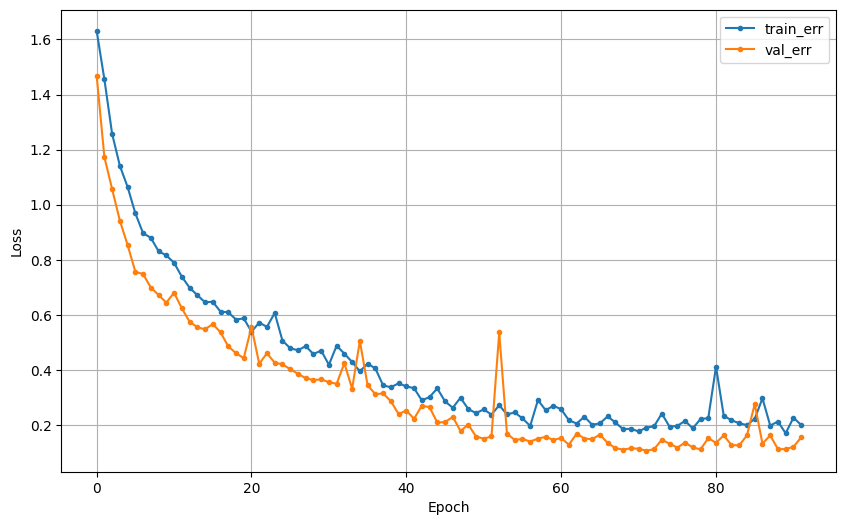

[[223   0   0   0   0   0]
 [  0 189  17   0   0   0]
 [  0   2 216   0   0   0]
 [  0   0   0 197   2   1]
 [  0   0   0   0 158   0]
 [  0   0   0   1   8 163]]
Accuracy: 0.9737
Precision: 0.9743
Recall: 0.9735
F1 Score: 0.9733
=== Model Training: Repeat 2/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


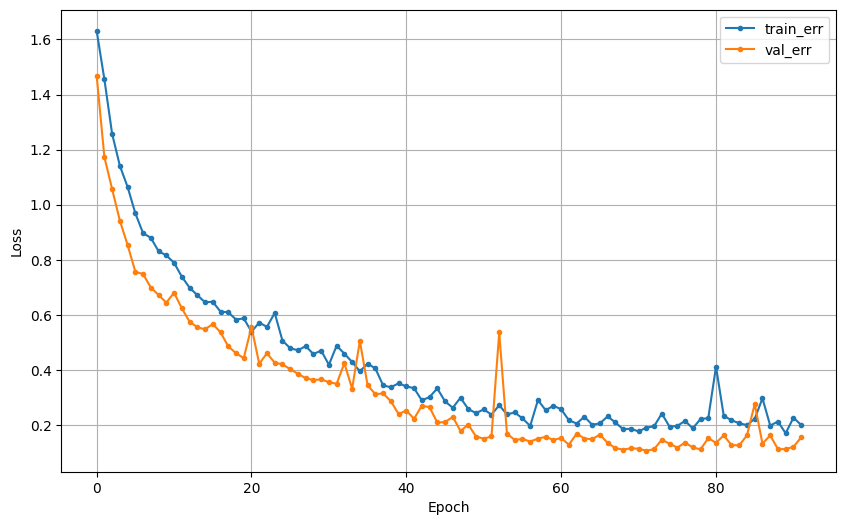

[[223   0   0   0   0   0]
 [  1 199   6   0   0   0]
 [  0   5 213   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   1   1 170]]
Accuracy: 0.9873
Precision: 0.9877
Recall: 0.9877
F1 Score: 0.9877
=== Model Training: Repeat 3/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


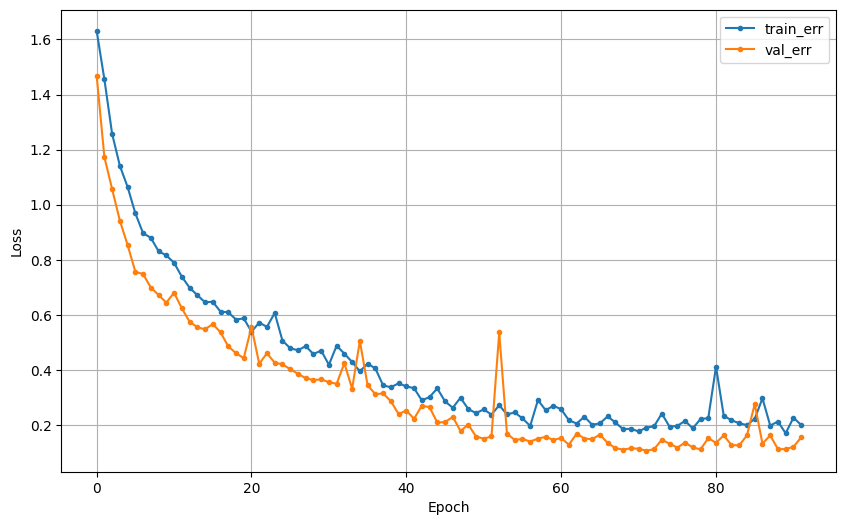

[[223   0   0   0   0   0]
 [  1 201   4   0   0   0]
 [  0   7 211   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   6   0 166]]
Accuracy: 0.9839
Precision: 0.9847
Recall: 0.9840
F1 Score: 0.9842
=== Model Training: Repeat 4/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


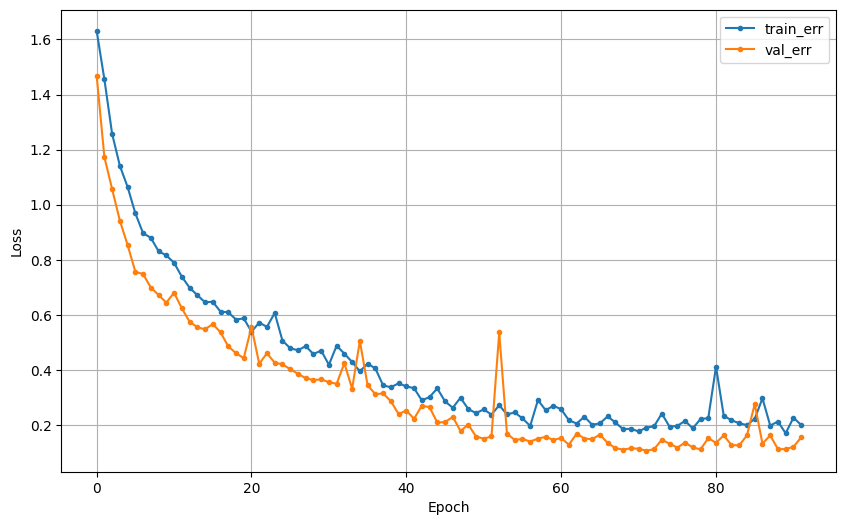

[[223   0   0   0   0   0]
 [  1 204   1   0   0   0]
 [  0  17 201   0   0   0]
 [  0   0   0 197   0   3]
 [  0   0   0   0 157   1]
 [  0   0   0   1   0 171]]
Accuracy: 0.9796
Precision: 0.9810
Recall: 0.9809
F1 Score: 0.9805
=== Model Training: Repeat 5/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


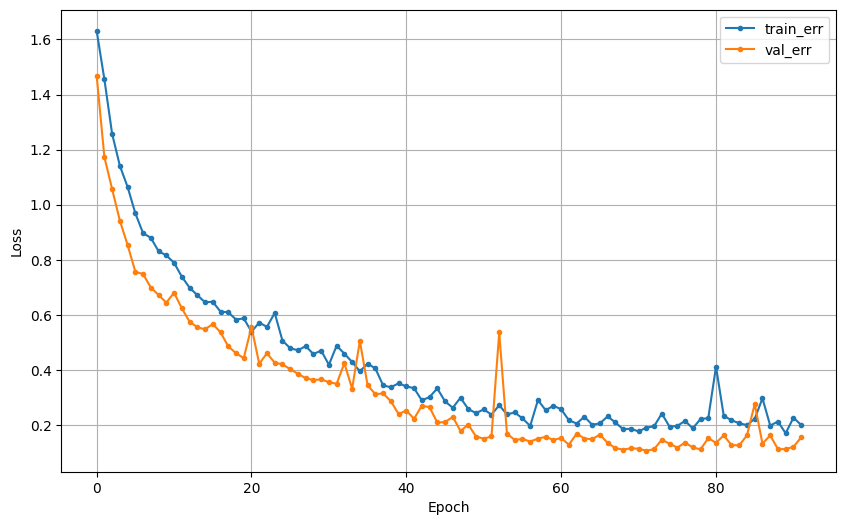

[[223   0   0   0   0   0]
 [  1 194  11   0   0   0]
 [  0   6 212   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   2   3 167]]
Accuracy: 0.9796
Precision: 0.9803
Recall: 0.9800
F1 Score: 0.9801

=== Average Results ===
Average Accuracy: 0.9808
Average Precision: 0.9816
Average Recall: 0.9812
Average F1 Score: 0.9812


In [87]:
n_repeats = 5
drop_rate=0.2

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []


for i in range(n_repeats):
  print(f"=== Model Training: Repeat {i+1}/{n_repeats} ===")

  clear_session()
  # 모델링
  model4 = Sequential([Input(shape=(nf, )),
                      Dense(400, activation='relu'),
                      Dropout(drop_rate),
                      Dense(200, activation='relu'),
                      Dropout(drop_rate),
                      Dense(100, activation='relu'),
                      Dropout(drop_rate),
                      Dense(50, activation='relu'),
                      Dropout(drop_rate),
                      Dense(10, activation='relu'),
                      Dropout(drop_rate),
                      Dense(6, activation='softmax')])

  # EarlyStopping 설정
  es = EarlyStopping(monitor='val_loss', min_delta=0.001, patience=30)
  # 컴파일 + 학습
  model4.compile(optimizer=Adam(learning_rate=0.001), loss = 'categorical_crossentropy')
  result4 = model4.fit(x_train, y_train, epochs=150, validation_split=0.2, callbacks = [es], verbose=0).history

  # 예측 및 성능 평가
  pred = model4.predict(x_val)
  pred_y = np.argmax(pred, axis=1)

  # 분류 보고서에서 주요 지표 추출
  report = classification_report(y_val, pred_y, output_dict=True)

  # 성능 지표 기록
  accuracy_list.append(report['accuracy'])
  precision_list.append(report['macro avg']['precision'])
  recall_list.append(report['macro avg']['recall'])
  f1_list.append(report['macro avg']['f1-score'])

  # 학습 곡선 출력
  dl_history_plot(hist)

  # 출력 (개별 결과)
  print(confusion_matrix(y_val, pred_y))
  print(f"Accuracy: {report['accuracy']:.4f}")
  print(f"Precision: {report['macro avg']['precision']:.4f}")
  print(f"Recall: {report['macro avg']['recall']:.4f}")
  print(f"F1 Score: {report['macro avg']['f1-score']:.4f}")
  print("==============================================")

# 평균값 출력
print("\n=== Average Results ===")
print(f"Average Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1 Score: {np.mean(f1_list):.4f}")

### (5) 모델5
- HL의 노드수를 증가 -> 감소 -> 증가 형식의 레이어 구성
- Dropout = 0.2
- es : min_delta = 0.0001, patience = 10

=== Model Training: Repeat 1/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


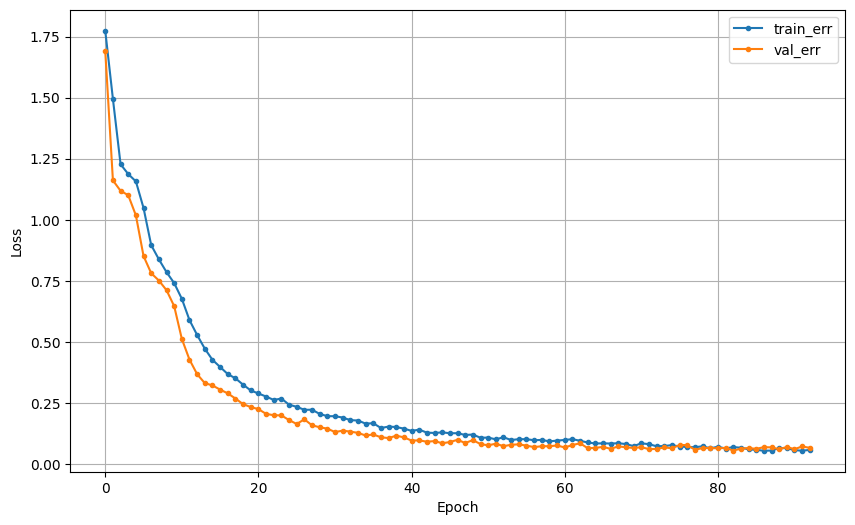

[[223   0   0   0   0   0]
 [  1 198   7   0   0   0]
 [  0  10 208   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   2   2 168]]
Accuracy: 0.9805
Precision: 0.9811
Recall: 0.9812
F1 Score: 0.9811
=== Model Training: Repeat 2/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


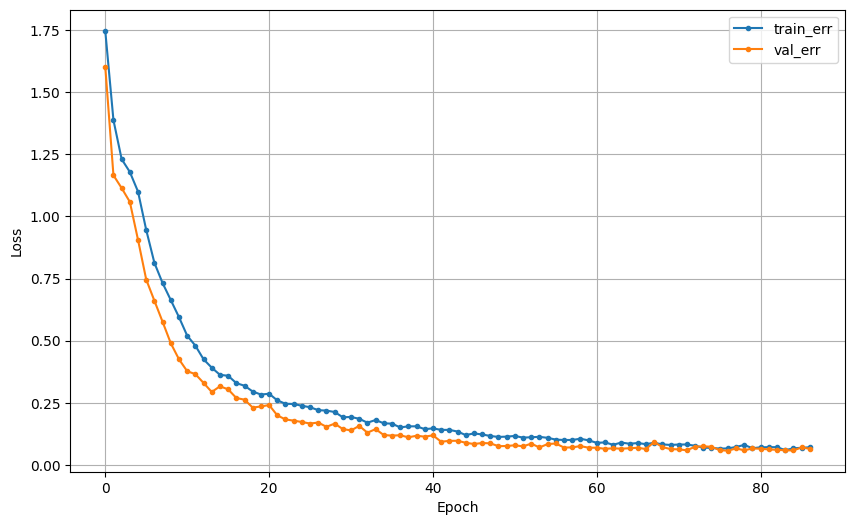

[[223   0   0   0   0   0]
 [  1 199   6   0   0   0]
 [  0  12 206   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   1   2 169]]
Accuracy: 0.9805
Precision: 0.9812
Recall: 0.9814
F1 Score: 0.9812
=== Model Training: Repeat 3/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


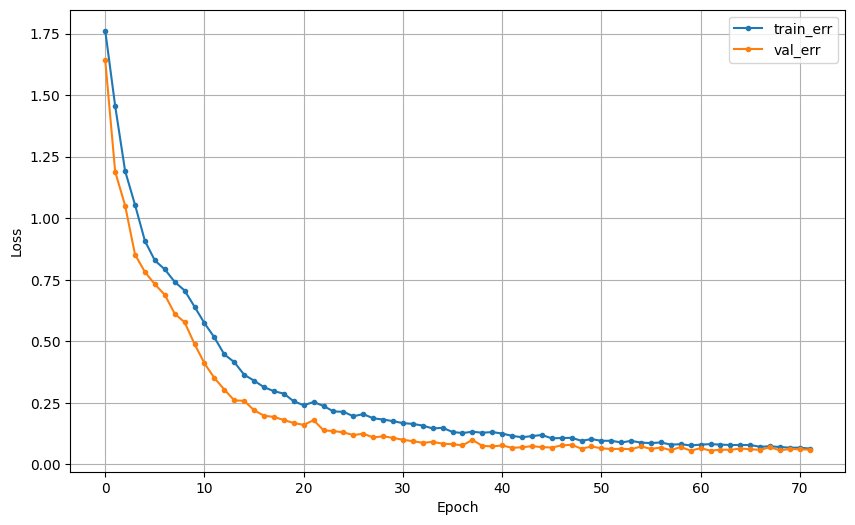

[[223   0   0   0   0   0]
 [  0 204   2   0   0   0]
 [  0  18 200   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   1   1 170]]
Accuracy: 0.9805
Precision: 0.9820
Recall: 0.9818
F1 Score: 0.9815
=== Model Training: Repeat 4/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


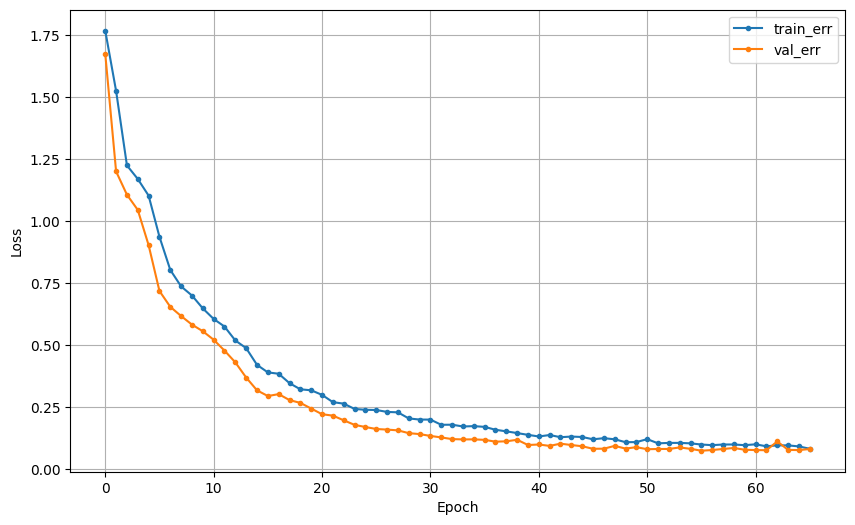

[[223   0   0   0   0   0]
 [  1 199   6   0   0   0]
 [  0  13 205   0   0   0]
 [  0   0   0 196   1   3]
 [  0   0   0   0 158   0]
 [  0   0   0   1   2 169]]
Accuracy: 0.9771
Precision: 0.9774
Recall: 0.9782
F1 Score: 0.9777
=== Model Training: Repeat 5/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


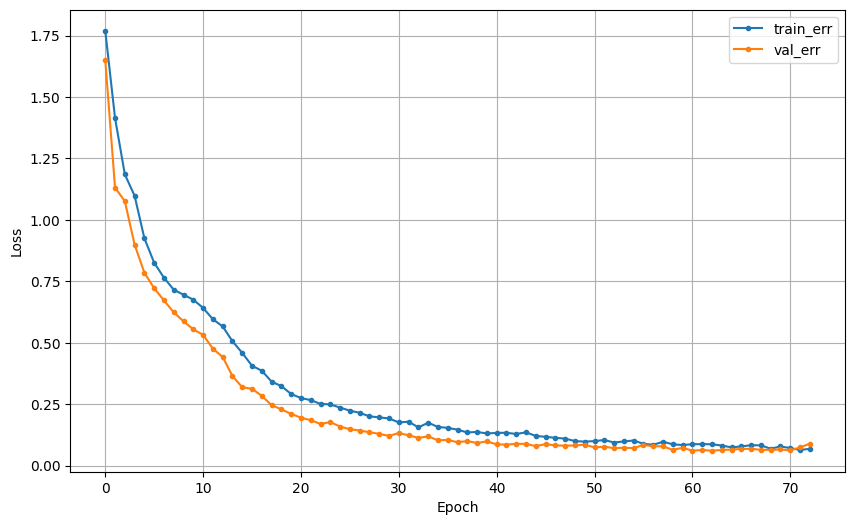

[[223   0   0   0   0   0]
 [  1 205   0   0   0   0]
 [  0  25 193   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   2   1 169]]
Accuracy: 0.9745
Precision: 0.9775
Recall: 0.9763
F1 Score: 0.9758

=== Average Results ===
Average Accuracy: 0.9786
Average Precision: 0.9798
Average Recall: 0.9798
Average F1 Score: 0.9795


In [88]:
n_repeats = 5
drop_rate=0.2

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []


for i in range(n_repeats):
  print(f"=== Model Training: Repeat {i+1}/{n_repeats} ===")
  clear_session()

  model3 = Sequential([Input(shape = (nf, )),
                          Dense(256, activation='relu'),
                          Dropout(0.3),
                          Dense(128, activation='relu'),
                          Dropout(0.3),
                          Dense(512, activation='relu'),
                          Dropout(0.3),
                          Dense(64, activation='relu'),
                          Dropout(0.2),
                          Dense(512, activation='relu'),
                          Dropout(0.2),
                          Dense(64, activation='relu'),
                          Dropout(0.2),
                          Dense(6, activation='softmax')])

  es = EarlyStopping(monitor = 'val_loss', min_delta = 0.0001, patience = 10)
  model3.compile(optimizer=Adam(learning_rate=0.00005), loss='categorical_crossentropy')
  hist = model3.fit(x_train, y_train, epochs = 100,validation_split=0.2, verbose=0, callbacks = [es]).history

  # 예측 및 성능 평가
  pred = model3.predict(x_val)
  pred_y = np.argmax(pred, axis=1)

  # 분류 보고서에서 주요 지표 추출
  report = classification_report(y_val, pred_y, output_dict=True)

  # 성능 지표 기록
  accuracy_list.append(report['accuracy'])
  precision_list.append(report['macro avg']['precision'])
  recall_list.append(report['macro avg']['recall'])
  f1_list.append(report['macro avg']['f1-score'])

  # 학습 곡선 출력
  dl_history_plot(hist)

  # 출력 (개별 결과)
  print(confusion_matrix(y_val, pred_y))
  print(f"Accuracy: {report['accuracy']:.4f}")
  print(f"Precision: {report['macro avg']['precision']:.4f}")
  print(f"Recall: {report['macro avg']['recall']:.4f}")
  print(f"F1 Score: {report['macro avg']['f1-score']:.4f}")
  print("==============================================")

# 평균값 출력
print("\n=== Average Results ===")
print(f"Average Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1 Score: {np.mean(f1_list):.4f}")

#### (6) 모델6
- Function API를 통해 5개의 HL 구현
- Dropout = 0.2

=== Model Training: Repeat 1/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


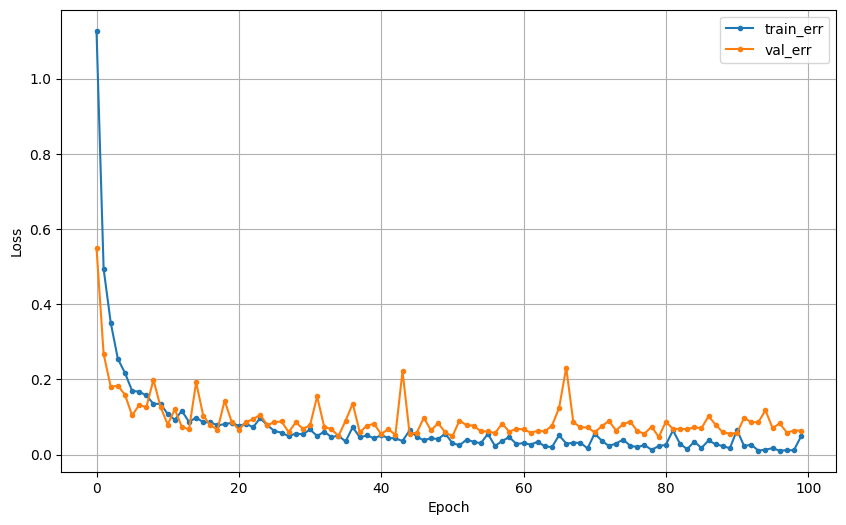

[[223   0   0   0   0   0]
 [  1 197   8   0   0   0]
 [  0   6 212   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   0   1 171]]
Accuracy: 0.9856
Precision: 0.9863
Recall: 0.9863
F1 Score: 0.9863
=== Model Training: Repeat 2/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


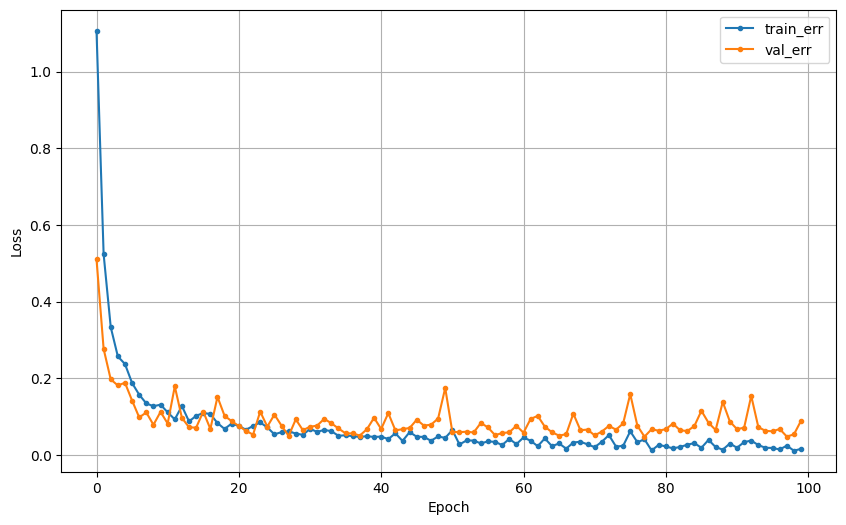

[[223   0   0   0   0   0]
 [  1 201   4   0   0   0]
 [  0   5 213   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   0   7 165]]
Accuracy: 0.9847
Precision: 0.9841
Recall: 0.9845
F1 Score: 0.9842
=== Model Training: Repeat 3/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


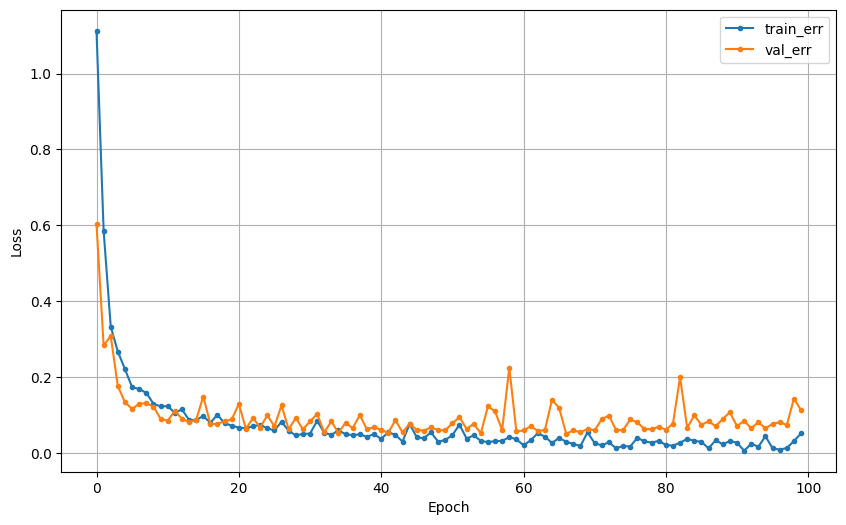

[[223   0   0   0   0   0]
 [  1 186  19   0   0   0]
 [  0   1 217   0   0   0]
 [  0   0   0 190   5   5]
 [  0   0   0   0 158   0]
 [  0   0   0   0   5 167]]
Accuracy: 0.9694
Precision: 0.9702
Recall: 0.9699
F1 Score: 0.9691
=== Model Training: Repeat 4/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


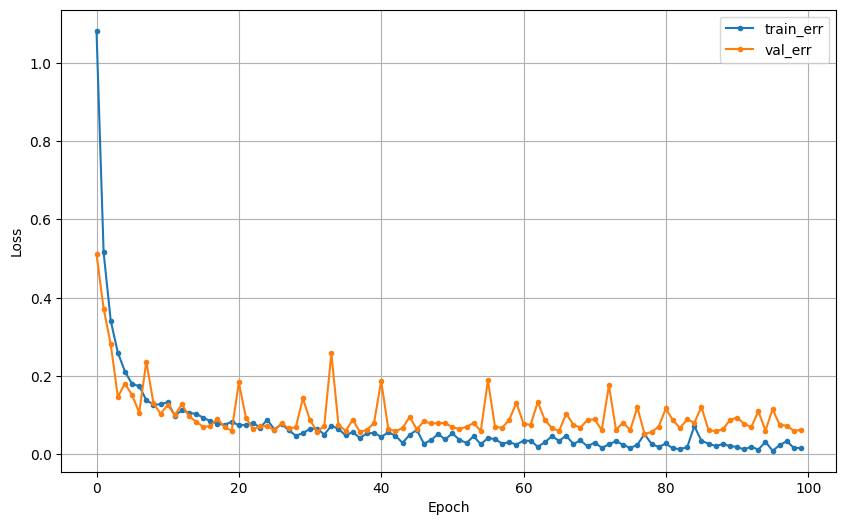

[[222   0   0   0   0   1]
 [  1 202   3   0   0   0]
 [  0   4 214   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   0   0 172]]
Accuracy: 0.9915
Precision: 0.9918
Recall: 0.9921
F1 Score: 0.9920
=== Model Training: Repeat 5/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


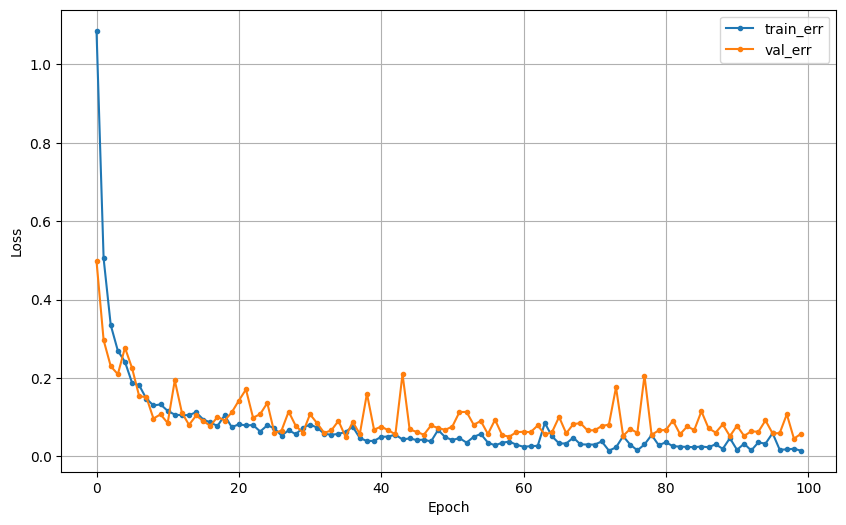

[[223   0   0   0   0   0]
 [  1 200   5   0   0   0]
 [  0   4 214   0   0   0]
 [  0   0   0 199   0   1]
 [  0   0   0   0 158   0]
 [  0   0   0   2   0 170]]
Accuracy: 0.9890
Precision: 0.9895
Recall: 0.9893
F1 Score: 0.9894

=== Average Results ===
Average Accuracy: 0.9840
Average Precision: 0.9844
Average Recall: 0.9844
Average F1 Score: 0.9842


In [89]:
n_repeats = 5

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []


for i in range(n_repeats):
  print(f"=== Model Training: Repeat {i+1}/{n_repeats} ===")

  clear_session()
  il = Input(shape=(nf,))
  x = Dense(512, activation='relu')(il)
  x = Dropout(0.2)(x)
  x = Dense(456, activation='relu')(x)
  x = Dropout(0.2)(x)
  x = Dense(306, activation='relu')(x)
  x = Dropout(0.2)(x)
  x = Dense(156, activation='relu')(x)
  x = Dropout(0.2)(x)
  x = Dense(56, activation='relu')(x)
  x = Dropout(0.2)(x)
  ol = Dense(6, activation='softmax')(x)

  model3 = Model(inputs = il, outputs = ol)

  # 모델 컴파일 및 학습
  model3.compile(optimizer= Adam(learning_rate = 0.0003), loss='categorical_crossentropy')
  hist = model3.fit(x_train, y_train,
                    validation_split=0.2,
                    epochs=100,
                    verbose=0).history

  # 예측 및 성능 평가
  pred = model3.predict(x_val)
  pred_y = np.argmax(pred, axis=1)

  # 분류 보고서에서 주요 지표 추출
  report = classification_report(y_val, pred_y, output_dict=True)

  # 성능 지표 기록
  accuracy_list.append(report['accuracy'])
  precision_list.append(report['macro avg']['precision'])
  recall_list.append(report['macro avg']['recall'])
  f1_list.append(report['macro avg']['f1-score'])

  # 학습 곡선 출력
  dl_history_plot(hist)

  # 출력 (개별 결과)
  print(confusion_matrix(y_val, pred_y))
  print(f"Accuracy: {report['accuracy']:.4f}")
  print(f"Precision: {report['macro avg']['precision']:.4f}")
  print(f"Recall: {report['macro avg']['recall']:.4f}")
  print(f"F1 Score: {report['macro avg']['f1-score']:.4f}")
  print("==============================================")

# 평균값 출력
print("\n=== Average Results ===")
print(f"Average Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1 Score: {np.mean(f1_list):.4f}")

### (7) 모델7
- 센서별로 Input layer 분리 진행
- es : min_delta=0.0001,patience=10

In [90]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Concatenate
train=pd.read_csv(path+'data01_train.csv')

In [91]:
train4=train.copy()
target='Activity'
x=train4.drop(target, axis=1)
y=train4[target]

x_train,x_test,y_train,y_test=train_test_split(x,y_o,test_size=0.2,random_state=10,stratify=y)

temp12=x_train.transpose().reset_index()
temp13=x_test.transpose().reset_index()

temp11=pd.merge(temp12,features,left_on='index',right_on='feature_name')
temp14=pd.merge(temp13,features,left_on='index',right_on='feature_name')

temp11.drop(columns=['axis','feature_name','agg'],inplace=True)
temp14.drop(columns=['axis','feature_name','agg'],inplace=True)

sensor_dfs_dict = {}
sensor_test_dfs_dict = {}
# Group by 'sensor' and create separate DataFrames for each sensor

for sensor_type, group in temp11.groupby('sensor'):
    # Drop the 'sensor' column and reset index
    sensor_dfs_dict[sensor_type] = group.drop(columns='sensor').set_index('index',drop=True).transpose()

for sensor_type, group in temp14.groupby('sensor'):
    # Drop the 'sensor' column and reset index
    sensor_test_dfs_dict[sensor_type] = group.drop(columns='sensor').set_index('index',drop=True).transpose()


In [92]:
def create_model(sensor_dfs_dict, num_classes):
    inputs = []
    sensor_outputs = []

    for sensor_type, df in sensor_dfs_dict.items():
        input_layer = Input(shape=(df.shape[1],), name=f'{sensor_type}_input')
        inputs.append(input_layer)

        x = Dense(128, activation='relu')(input_layer)
        x = Dense(64, activation='relu')(x)

        sensor_outputs.append(x)

    if len(sensor_outputs) > 1:
        merged = Concatenate()(sensor_outputs)
    else:
        merged = sensor_outputs[0]

    x = Dense(64, activation='relu')(merged)
    x = Dense(32, activation='relu')(x)

    output_layer = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=output_layer)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model


=== Model Training: Repeat 1/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


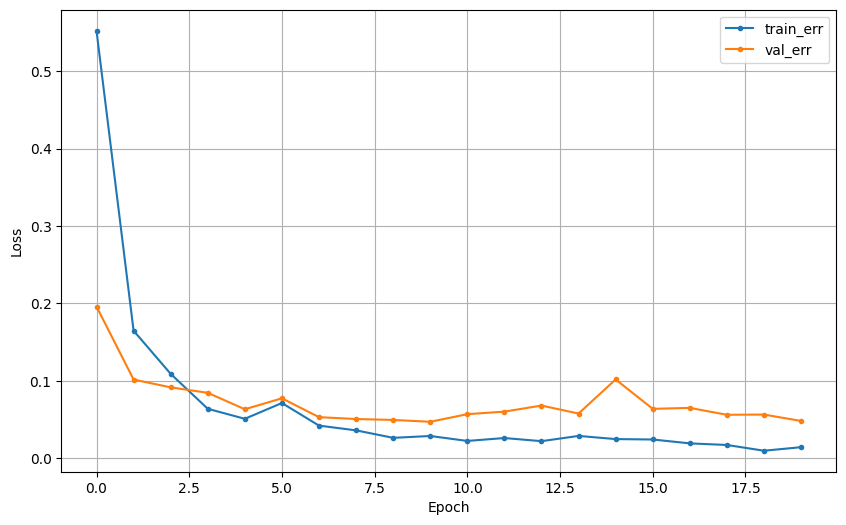

[[223   0   0   0   0   0]
 [  0 196  10   0   0   0]
 [  0   9 209   0   0   0]
 [  0   0   0 199   1   0]
 [  0   0   0   0 158   0]
 [  0   0   0   1   0 171]]
Accuracy: 0.9822
Precision: 0.9832
Recall: 0.9832
F1 Score: 0.9832
=== Model Training: Repeat 2/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


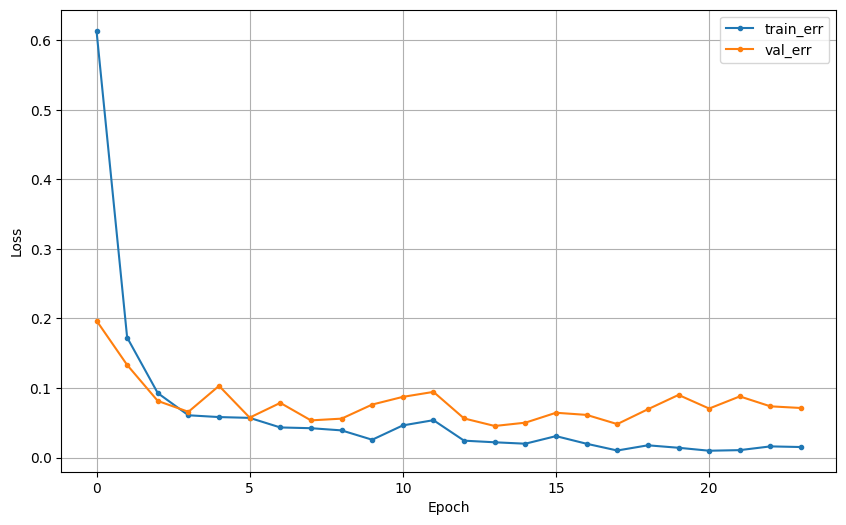

[[223   0   0   0   0   0]
 [  0 203   3   0   0   0]
 [  0  13 205   0   0   0]
 [  0   0   0 199   1   0]
 [  0   0   0   0 158   0]
 [  0   0   0   0   0 172]]
Accuracy: 0.9856
Precision: 0.9865
Recall: 0.9868
F1 Score: 0.9865
=== Model Training: Repeat 3/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


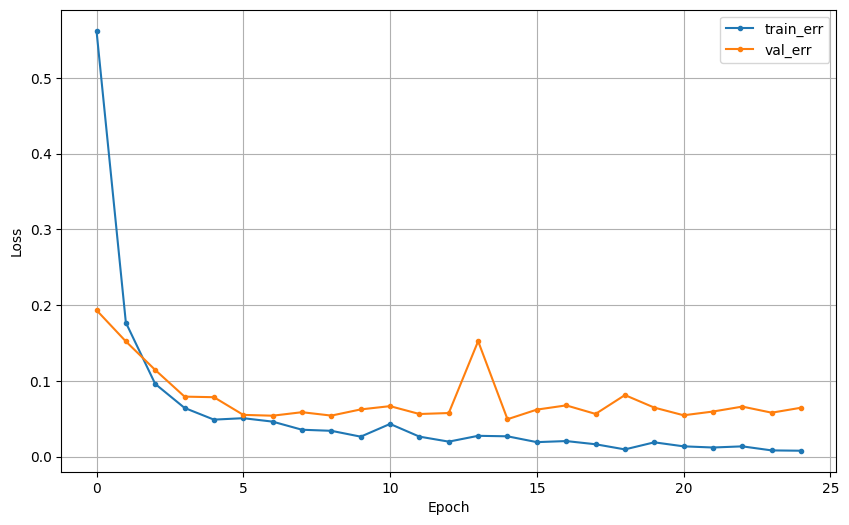

[[223   0   0   0   0   0]
 [  0 189  17   0   0   0]
 [  0   9 209   0   0   0]
 [  0   0   0 199   1   0]
 [  0   0   0   0 158   0]
 [  0   0   0   0   1 171]]
Accuracy: 0.9762
Precision: 0.9778
Recall: 0.9776
F1 Score: 0.9776
=== Model Training: Repeat 4/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


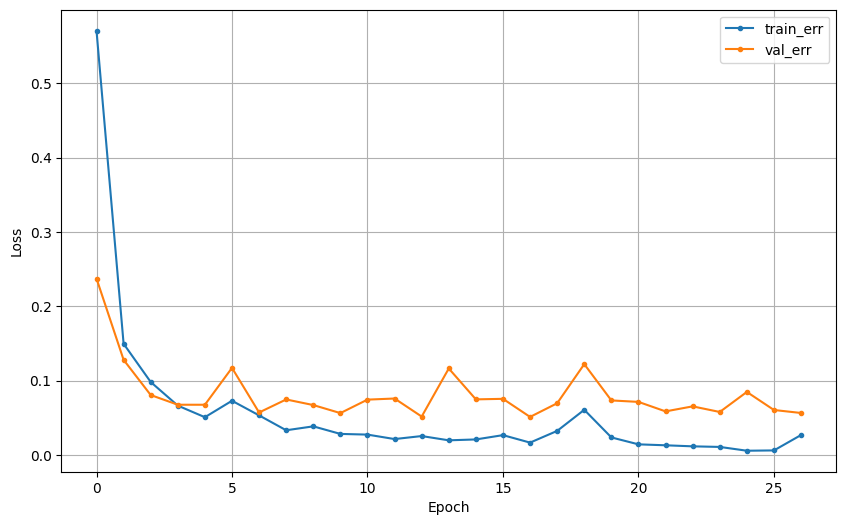

[[223   0   0   0   0   0]
 [  0 198   8   0   0   0]
 [  0   8 210   0   0   0]
 [  0   0   0 199   1   0]
 [  0   0   0   0 158   0]
 [  0   0   0   1   1 170]]
Accuracy: 0.9839
Precision: 0.9845
Recall: 0.9846
F1 Score: 0.9846
=== Model Training: Repeat 5/5 ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


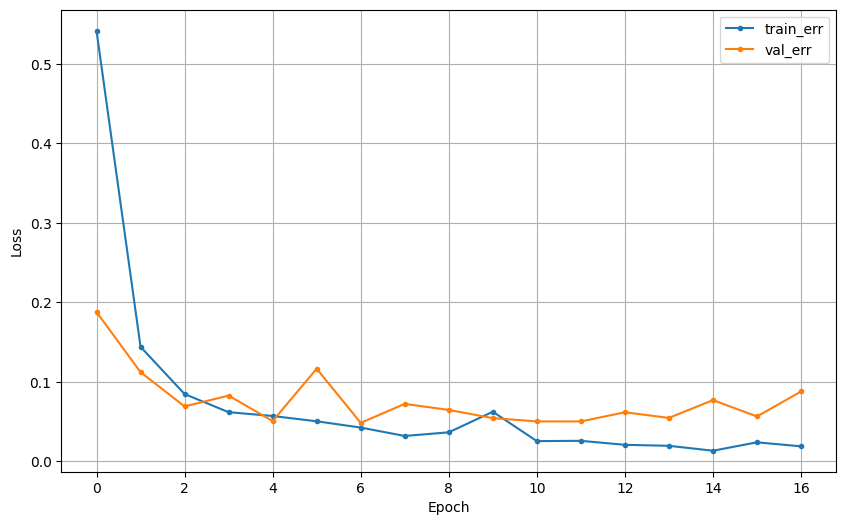

[[223   0   0   0   0   0]
 [  0 202   4   0   0   0]
 [  0  22 196   0   0   0]
 [  0   0   0 199   1   0]
 [  0   0   0   0 158   0]
 [  0   0   0   1   1 170]]
Accuracy: 0.9754
Precision: 0.9774
Recall: 0.9772
F1 Score: 0.9767

=== Average Results ===
Average Accuracy: 0.9806
Average Precision: 0.9819
Average Recall: 0.9819
Average F1 Score: 0.9817


In [98]:
n_repeats = 5
drop_rate=0.2

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []


for i in range(n_repeats):
  print(f"=== Model Training: Repeat {i+1}/{n_repeats} ===")
  clear_session()

  num_classes = 6

  clear_session()
  model = create_model(sensor_dfs_dict, num_classes)
  # Convert all input data in X_train_list to float32
  X_train_list = [np.array(sensor_dfs_dict[sensor_type], dtype=np.float32) for sensor_type in sensor_dfs_dict]
  X_test_list = [np.array(sensor_test_dfs_dict[sensor_type], dtype=np.float32) for sensor_type in sensor_test_dfs_dict]
  y_train = np.array(y_train, dtype=np.float32)
  y_test = np.array(y_test, dtype=np.float32)
  es = EarlyStopping(monitor = 'val_loss', min_delta = 0.0001, patience = 10)

  # Train the model using the prepared input lists
  history = model.fit(
      X_train_list,  # List of X_train arrays from each sensor type
      y_train,  # y_train should be the same for all sensor types
      validation_split=0.2,
      epochs=50,
      callbacks=[es],
      verbose=0
  ).history


  # 예측 및 성능 평가
  pred=model.predict(X_test_list)
  pred_y = np.argmax(pred, axis=1)
  #y_test=np.argmax(y_test,axis=1)
  # 분류 보고서에서 주요 지표 추출
  report = classification_report(y_test, pred_y, output_dict=True)

  # 성능 지표 기록
  accuracy_list.append(report['accuracy'])
  precision_list.append(report['macro avg']['precision'])
  recall_list.append(report['macro avg']['recall'])
  f1_list.append(report['macro avg']['f1-score'])

  # 학습 곡선 출력
  dl_history_plot(history)

  # 출력 (개별 결과)
  print(confusion_matrix(y_test, pred_y))
  print(f"Accuracy: {report['accuracy']:.4f}")
  print(f"Precision: {report['macro avg']['precision']:.4f}")
  print(f"Recall: {report['macro avg']['recall']:.4f}")
  print(f"F1 Score: {report['macro avg']['f1-score']:.4f}")
  print("==============================================")

# 평균값 출력
print("\n=== Average Results ===")
print(f"Average Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Average Precision: {np.mean(precision_list):.4f}")
print(f"Average Recall: {np.mean(recall_list):.4f}")
print(f"Average F1 Score: {np.mean(f1_list):.4f}")

## 4.성능비교

* 세부 요구사항
    - test 데이터에 대한 전처리
    - 각 모델에 대해서 test 데이터로 성능 측정